In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import FashionMNIST, MNIST
import torchvision.transforms as transforms
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [81]:
# ============================================================
# Settings
# ============================================================

BATCH_SIZE = 256
EPOCHS = 20
IMG_SIZE = 28


In [109]:
which_model = 'mlp'

In [4]:

def straight_line_texture(
    size=28,
    line_width=1,
    spacing=3,
    angle_range=(0, 45),
    seed=None
):
    """
    Generates straight parallel lines and rotates the entire pattern randomly.

    Parameters:
        size        : output size (28)
        line_width  : line thickness in pixels
        spacing     : distance between lines
        angle_range : (min_angle, max_angle)
        seed        : optional RNG seed

    Returns:
        uint8 2D array of size (size, size)
    """
    rng = np.random.default_rng(seed)

    # 1. Large canvas for rotation (to avoid cropping artifacts)
    big = size * 2  
    texture = np.full((big, big), 255, dtype=np.uint8)

    # 2. Draw horizontal lines
    for y in range(0, big, spacing):
        texture[y:y+line_width, :] = 0

    # 3. Pick random rotation angle
    angle = rng.uniform(angle_range[0], angle_range[1])

    # 4. Rotate texture
    M = cv2.getRotationMatrix2D((big/2, big/2), angle, 1.0)
    rotated = cv2.warpAffine(texture, M, (big, big), flags=cv2.INTER_LINEAR, borderValue=255)

    # 5. Center crop back to 28×28
    start = big//2 - size//2
    end   = start + size
    final = rotated[start:end, start:end]

    return final.astype(np.uint8)


In [5]:

def tiny_dot_texture(
    size=28,
    spacing=2,
    shift_range=3,
    seed=None
):
    """
    Generate a 28x28 texture with tiny single-pixel dots arranged on an
    evenly-spaced grid that is randomly shifted.
    """

    rng = np.random.default_rng(seed)
    tex = np.full((size, size), 255, dtype=np.uint8)

    # random global offset for the grid
    shift_x = rng.integers(-shift_range, shift_range + 1)
    shift_y = rng.integers(-shift_range, shift_range + 1)

    # place tiny (1px) dots
    for y in range(shift_y, size, spacing):
        for x in range(shift_x, size, spacing):
            if 0 <= x < size and 0 <= y < size:
                tex[y, x] = 0    # small dot

    return tex


In [6]:

# ============================================================
# Helper Functions
# ============================================================

# ---- Your modified function ----
def make_digit_on_bg(img_uint8, label):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture() if label == 0 else straight_line_texture()

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[~mask] = 255  # Zero out areas outside the mask

    return bg



def make_digit_on_bg_w_edge(img_uint8, label):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture() if label == 0 else straight_line_texture()
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # edges = cv2.Canny(img_uint8, 50, 150)
    edges = binary_edges(img_uint8.numpy())
    edge_mask = edges > 0

    # edge_mask = cv2.dilate(edge_mask.astype(np.uint8),
    #                        np.ones((1,1), np.uint8),
    #                        iterations=1).astype(bool)
    
    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[mask] = 255  # Zero out areas outside the mask

    bg[edge_mask] = 0 
    
    return bg



def make_digit_on_bg_cueconflict(img_uint8, label):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture() if label == 1 else straight_line_texture()

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0


    # edges = cv2.Canny(img_uint8, 50, 150)
    edges = binary_edges(img_uint8.numpy())
    edge_mask = edges > 0

    
    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[mask] = 255  # Zero out areas outside the mask

    bg[edge_mask] = 0 
    
    return bg



def make_digit_on_random_bg(img_uint8):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = random.choice([tiny_dot_texture(), straight_line_texture()])
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[mask] = 255  # Zero out areas outside the mask

    return bg



def make_digit_on_dot_bg(img_uint8):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture()
    # n_bg = random.choice([tiny_dot_texture, straight_line_texture])
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[mask] = 255  # Zero out areas outside the mask

    return bg




def make_digit_on_line_bg(img_uint8):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = straight_line_texture()
    # n_bg = random.choice([tiny_dot_texture, straight_line_texture])
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[mask] = 255  # Zero out areas outside the mask

    return bg





def edges_on_whitebg(img_uint8, label):
    # edges = cv2.Canny(img_uint8, 50, 150)
    edges = binary_edges(img_uint8.numpy())
    
    edge_mask = edges > 0
    bg_val = 255
    bg = np.full((IMG_SIZE, IMG_SIZE), bg_val, dtype=np.uint8)
    bg[edge_mask] = 0  # edges = black
    return bg



def bg_only(label):
    return  tiny_dot_texture() if label == 0 else straight_line_texture()



def to_tensor(x):
    return torch.tensor(x / 255.0, dtype=torch.float32).unsqueeze(0)



In [100]:

#   ============================================================
#   Model (simple CNN)
#   ============================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=5, padding=2), nn.ReLU(),   # First layer: 4 filters
            nn.MaxPool2d(2),
            nn.Conv2d(4, 8, kernel_size=5, padding=2), nn.ReLU(),   # Second layer: 8 filters
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 7 * 7, 32), nn.ReLU(),  # Adjusted for final feature map size
            nn.Linear(32, 2)  # Output for 2 classes
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# ============================================================
# Model (simple CNN)
# ============================================================

class SimpleViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, dim=64, depth=4, heads=4, mlp_dim=128, num_classes=2):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        num_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size  # For grayscale MNIST (1 channel)

        # Patch embedding
        self.patch_embed = nn.Linear(patch_dim, dim)

        # Positional embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Classification head
        self.fc = nn.Linear(dim, num_classes)
        

    def forward(self, x):
        # x: [batch, 1, 28, 28]
        B = x.size(0)
        # Split into patches
        patches = x.unfold(2, 7, 7).unfold(3, 7, 7)  # [B, 1, 4, 4, 7, 7]
        patches = patches.contiguous().view(B, -1, 7*7)  # [B, num_patches, patch_dim]

        # Embed patches
        tokens = self.patch_embed(patches)  # [B, num_patches, dim]

        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)  # [B, num_patches+1, dim]

        # Add positional embedding
        tokens = tokens + self.pos_embedding

        # Transformer
        tokens = tokens.permute(1, 0, 2)  # [seq_len, batch, dim]
        encoded = self.transformer(tokens)  # [seq_len, batch, dim]

        # Take CLS token output
        cls_out = encoded[0]  # [batch, dim]

        return cls_out




class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # First hidden layer
        self.fc2 = nn.Linear(128, 64)       # Second hidden layer
        self.fc3 = nn.Linear(64, 2)        # Output layer (2 classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)           # Flatten: (batch, 784)
        # print(x.shape)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                     # No softmax here (handled by loss)
        return x

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import random


class ShapeDataset(Dataset):
    def __init__(self, n_samples=10000, img_size=64, margin=3):
        self.n_samples = n_samples
        self.img_size = img_size
        self.margin = margin  # extra border so shapes never touch edges

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):

        img = np.ones((self.img_size, self.img_size), dtype=np.uint8) * 255
        
        # 0 = circle, 1 = square
        label = random.randint(0, 1)

        # Size range
        min_size = self.img_size // 8
        max_size = self.img_size // 3
        size = random.randint(min_size, max_size)

        # Allowed coordinate range so shape never touches boundary
        low = size + self.margin
        high = self.img_size - size - self.margin

        cx = random.randint(low, high)
        cy = random.randint(low, high)

        if label == 0:
            # Draw circle
            cv2.circle(img, (cx, cy), size, (0,), -1)
        else:
            # Draw square
            x1, y1 = cx - size, cy - size
            x2, y2 = cx + size, cy + size
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,), -1)

        img = torch.tensor(img, dtype=torch.uint8).unsqueeze(0)
        return img, label


# Example
train_dataset = ShapeDataset(n_samples=5000, img_size=64)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Test
images, labels = next(iter(train_loader))
print(images.shape, labels[:10])


torch.Size([32, 1, 64, 64]) tensor([1, 1, 1, 1, 1, 0, 1, 1, 0, 1])


In [66]:
def binary_edges(img):
    # img is 0 or 255
    kernel = np.ones((3,3), np.uint8)
    eroded = cv2.erode(img, kernel, iterations=1)
    edges = img - eroded
    return edges

# for i in range(2):
#     # plt.imshow(binary_edges(images[i].squeeze(0).numpy())); plt.show()
#     # plt.imshow(images[i].squeeze(0).numpy()); plt.show()
    
#     plt.imshow(train_dataset[i][0].squeeze(0)); plt.show()
#     print(train_dataset[i][1])        

#     # images
#     # print(labels[i])

In [96]:
from torch.utils.data import TensorDataset, DataLoader

def make_loader(pairs, batch_size=32, shuffle=False):
    imgs = torch.stack([p[0] for p in pairs])  # [N,1,H,W]
    labels = torch.tensor([p[1] for p in pairs], dtype=torch.long)
    return DataLoader(TensorDataset(imgs, labels),
                      batch_size=batch_size,
                      shuffle=shuffle)


In [110]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

results = []

for run_no in range(10):

    # ============================================================
    # Download MNIST
    # ============================================================

    # ======================================
    # Build raw datasets + dataloaders
    # ======================================
    train_dataset = ShapeDataset(n_samples=5000, img_size=28)
    train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

    test_dataset  = ShapeDataset(n_samples=2000, img_size=28)
    test_loader   = DataLoader(test_dataset, batch_size=32, shuffle=False)


    # ======================================
    # Collect all train / test samples via loaders
    # ======================================
    train_imgs  = []
    train_labels = []

    for imgs, labels in train_loader:
        # imgs: [B,1,H,W]
        for img, lbl in zip(imgs, labels):
            train_imgs.append(img.squeeze(0))  # → [H,W]
            train_labels.append(lbl.item())

    test_imgs  = []
    test_labels = []

    for imgs, labels in test_loader:
        for img, lbl in zip(imgs, labels):
            test_imgs.append(img.squeeze(0))
            test_labels.append(lbl.item())

    print("Train filtered:", len(train_imgs))
    print("Test filtered:", len(test_imgs))


    # ======================================
    # Build Training Set (digit on background)
    # ======================================
    train_data = [
        (to_tensor(make_digit_on_bg_w_edge(img, lbl)), lbl)
        for img, lbl in zip(train_imgs, train_labels)
    ]


    # ======================================
    # Build Test Sets A–G
    # ======================================
    test_A = [
        (to_tensor(make_digit_on_bg_w_edge(img, lbl)), lbl)
        for img, lbl in zip(test_imgs, test_labels)
    ]

    test_B = [
        (to_tensor(make_digit_on_bg_cueconflict(img, lbl)), lbl)
        for img, lbl in zip(test_imgs, test_labels)
    ]

    test_C = [
        (to_tensor(bg_only(lbl)), lbl)
        for lbl in test_labels
    ]

    test_D = [
        (to_tensor(edges_on_whitebg(img, lbl)), lbl)
        for img, lbl in zip(test_imgs, test_labels)
    ]

    test_E = [
        (to_tensor(make_digit_on_random_bg(img)), lbl)
        for img, lbl in zip(test_imgs, test_labels)
    ]

    test_F = [
        (to_tensor(make_digit_on_dot_bg(img)), lbl)
        for img, lbl in zip(test_imgs, test_labels)
    ]

    test_G = [
        (to_tensor(make_digit_on_line_bg(img)), lbl)
        for img, lbl in zip(test_imgs, test_labels)
    ]



    train_loader = make_loader(train_data, batch_size=32, shuffle=True)

    testA_loader = make_loader(test_A)
    testB_loader = make_loader(test_B)
    testC_loader = make_loader(test_C)
    testD_loader = make_loader(test_D)
    testE_loader = make_loader(test_E)
    testF_loader = make_loader(test_F)
    testG_loader = make_loader(test_G)



    if which_model.lower() == 'cnn':
        model = SimpleCNN().to(device)
    elif which_model.lower() == 'mlp':
        model = SimpleMLP().to(device)        
    else: 
        model = SimpleViT().to(device)



    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # ============================================================
    # Training Loop
    # ============================================================



    print("\n=== Training ===")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            imgs = imgs.float() # / 255.0
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f}")


    # ============================================================
    # Evaluation
    # ============================================================

    def evaluate(loader):
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                imgs = imgs.float() #/ 255.0
                preds = model(imgs).argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        return correct / total


    accA = evaluate(testA_loader)
    accB = evaluate(testB_loader)
    accC = evaluate(testC_loader)
    accD = evaluate(testD_loader)
    accE = evaluate(testE_loader)
    accF = evaluate(testE_loader)
    accG = evaluate(testE_loader)



    print("\n=== Final Accuracies ===")
    print(f"Test A: {accA:.4f}")
    print(f"Test B: {accB:.4f}")
    print(f"Test C: {accC:.4f}")
    print(f"Test D: {accD:.4f}")
    print(f"Test E: {accE:.4f}")
    print(f"Test F: {accF:.4f}")
    print(f"Test G: {accG:.4f}")


    results.append((accA, accB, accC, accD, accE, accF, accG))


Train filtered: 5000
Test filtered: 2000

=== Training ===
Epoch 1/20 - Loss: 0.4593
Epoch 2/20 - Loss: 0.2339
Epoch 3/20 - Loss: 0.2103
Epoch 4/20 - Loss: 0.2163
Epoch 5/20 - Loss: 0.1647
Epoch 6/20 - Loss: 0.1794
Epoch 7/20 - Loss: 0.2048
Epoch 8/20 - Loss: 0.1745
Epoch 9/20 - Loss: 0.1840
Epoch 10/20 - Loss: 0.1460
Epoch 11/20 - Loss: 0.1681
Epoch 12/20 - Loss: 0.1440
Epoch 13/20 - Loss: 0.1619
Epoch 14/20 - Loss: 0.1508
Epoch 15/20 - Loss: 0.1590
Epoch 16/20 - Loss: 0.1522
Epoch 17/20 - Loss: 0.1333
Epoch 18/20 - Loss: 0.1321
Epoch 19/20 - Loss: 0.1465
Epoch 20/20 - Loss: 0.1293

=== Final Accuracies ===
Test A: 0.9430
Test B: 0.1930
Test C: 0.7860
Test D: 0.6315
Test E: 0.5230
Test F: 0.5230
Test G: 0.5230
Train filtered: 5000
Test filtered: 2000

=== Training ===
Epoch 1/20 - Loss: 0.4529
Epoch 2/20 - Loss: 0.2244
Epoch 3/20 - Loss: 0.2102
Epoch 4/20 - Loss: 0.1910
Epoch 5/20 - Loss: 0.1640
Epoch 6/20 - Loss: 0.1792
Epoch 7/20 - Loss: 0.1678
Epoch 8/20 - Loss: 0.1520
Epoch 9/20 -

In [111]:
np.array(results).mean(axis=0)

array([0.93075, 0.19905, 0.8141 , 0.62475, 0.5003 , 0.5003 , 0.5003 ])

In [112]:
np.array(results).std(axis=0)

array([0.00888046, 0.00875628, 0.09127426, 0.01165815, 0.01637559,
       0.01637559, 0.01637559])

In [104]:
which_model

'vit'

[1775, 1879, 524, 1733, 293]


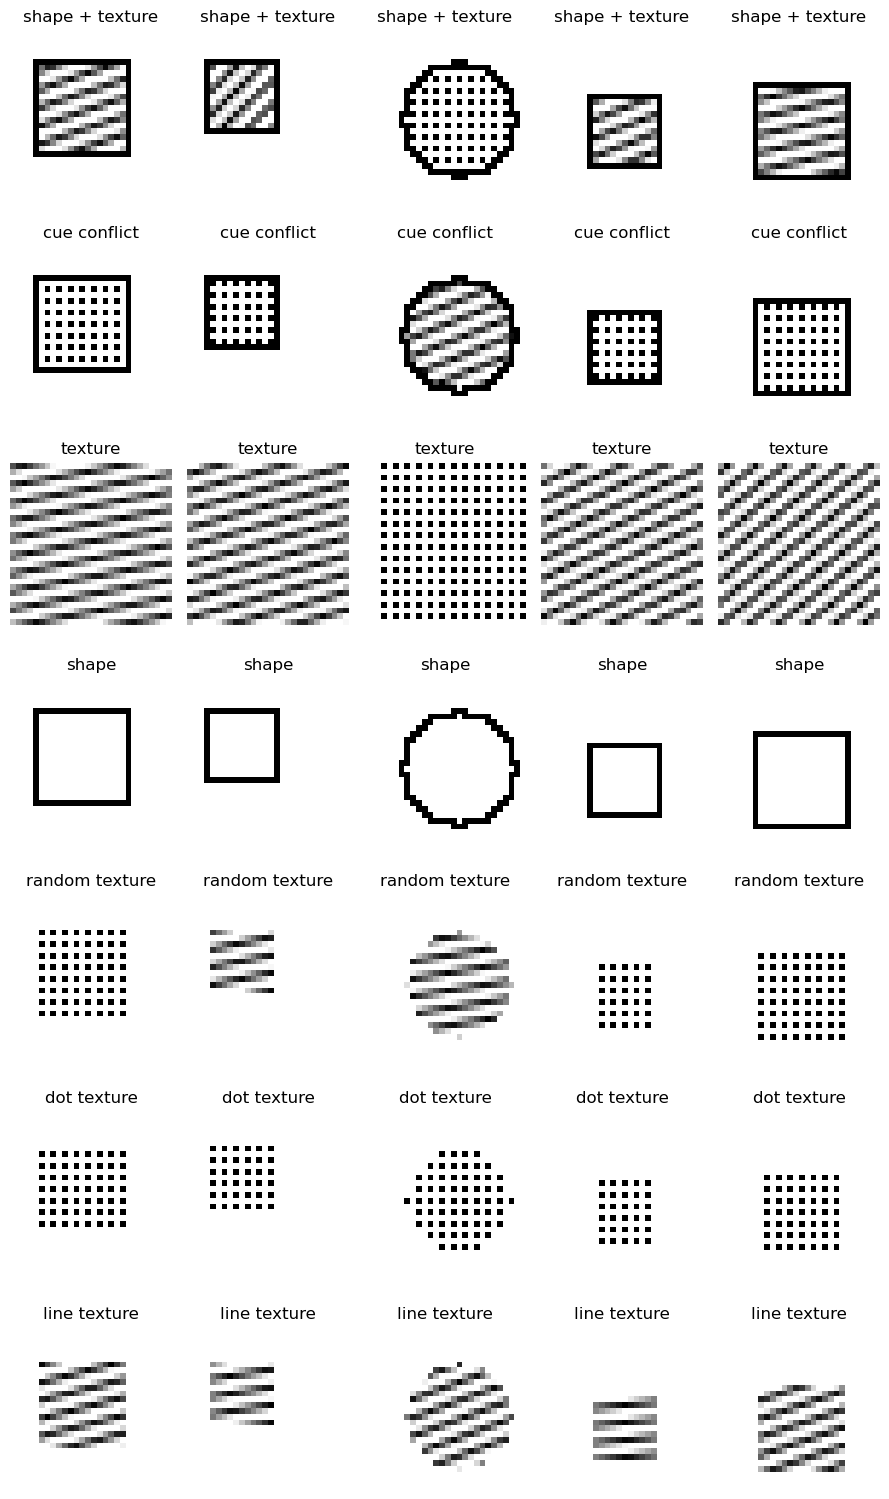

In [113]:

import random
import matplotlib.pyplot as plt

def show_matched_samples(n=2):
    # Safety check if test_imgs is shorter than n
    if len(test_imgs) < n:
        raise ValueError(f"Requested n={n}, but only {len(test_imgs)} samples are available.")

    idxs = random.sample(range(len(test_imgs)), n)
    print(idxs)

    rows = 7  # a, b, c, d, e, f, g
    fig, axes = plt.subplots(rows, n, figsize=(1.8*n, 2.2*rows), squeeze=False)

    for col, idx in enumerate(idxs):
        a = test_A[idx][0].squeeze().cpu().numpy()
        b = test_B[idx][0].squeeze().cpu().numpy()
        c = test_C[idx][0].squeeze().cpu().numpy()
        d = test_D[idx][0].squeeze().cpu().numpy()
        e = test_E[idx][0].squeeze().cpu().numpy()
        f = test_F[idx][0].squeeze().cpu().numpy()
        g = test_G[idx][0].squeeze().cpu().numpy()

        imgs  = [a, b, c, d, e, f, g]

        titles = ["shape + texture", 
                  "cue conflict", 
                  "texture", 
                  "shape", 
                  "random texture", 
                  "dot texture", 
                  "line texture"]


        for row in range(rows):
            ax = axes[row, col]
            ax.imshow(imgs[row], cmap="gray", vmin=0, vmax=1)
            ax.set_title(titles[row])
            ax.axis("off")

    plt.tight_layout()
    plt.show()


show_matched_samples(5)


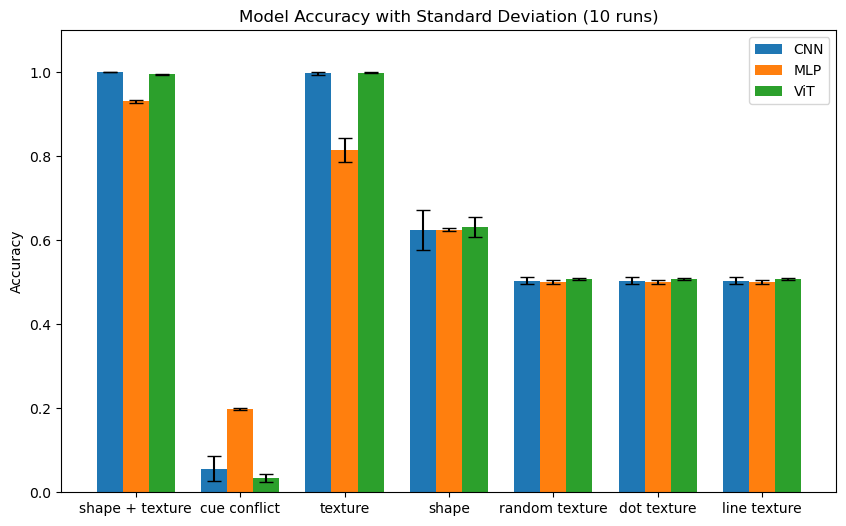

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# Data
labels = ["shape + texture", 
            "cue conflict", 
            "texture", 
            "shape", 
            "random texture", 
            "dot texture", 
            "line texture"]
# CNN
cnn_acc = np.array([1.0, 0.05655, 0.9971, 0.62485, 0.5039, 0.5039, 0.5039])
cnn_std = np.array([0.0, 0.09439053, 0.0087, 0.15250935, 0.0240539, 0.0240539, 0.0240539]) / np.sqrt(10)

# MLP
mlp_acc = np.array([0.93075, 0.19905, 0.8141, 0.62475, 0.5003, 0.5003, 0.5003])
mlp_std = np.array([0.00888046, 0.00875628, 0.09127426, 0.01165815, 0.01637559, 0.01637559, 0.01637559]) / np.sqrt(10)

# ViT
vit_acc = np.array([0.99515, 0.03315, 0.999, 0.63155, 0.5077, 0.5077, 0.5077]) 
vit_std = np.array([0.00247032, 0.03005, 0.003, 0.07615525, 0.01019363, 0.01019363, 0.01019363]) / np.sqrt(10)

# Set up the figure
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

# Plot accuracies with error bars
ax.bar(x - width, cnn_acc, width, yerr=cnn_std, capsize=5, label='CNN')
ax.bar(x, mlp_acc, width, yerr=mlp_std, capsize=5, label='MLP')
ax.bar(x + width, vit_acc, width, yerr=vit_std, capsize=5, label='ViT')

# Labels and styling
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy with Standard Deviation (10 runs)')
ax.legend()
ax.set_ylim(0, 1.1)

plt.show()
